# ADHD Classification with Cross-View VICReg Self-Supervised Pretraining + Dual-View Attention MIL

This notebook first pretrains an EEG encoder **without labels** so that the Full and Simple preprocessing views of each two-second epoch map to similar representations (the VICReg objective). The pretrained encoder is then transferred into a Dual-View Attention MIL classifier and fine-tuned with patient diagnoses. Each patient is a bag of epochs; attention selects the informative epochs and produces one patient-level prediction.

## 1. Setup

We import the required libraries, set random seeds, and select GPU when it is available.

In [2]:
import copy
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Load the preprocessed data

The notebook finds the two pickle files attached through Kaggle Input and loads them.

Each epoch is `channels x time = 15 x 256` (2 seconds at 128 Hz). Fifteen of the original nineteen 10-20 electrodes are retained; the four temporal electrodes (T7/T8/P7/P8) were dropped during preprocessing. Both files hold the same 16,749 epochs from 121 patients (61 ADHD, 60 Control), with per-epoch, per-channel z-scoring already applied.

In [3]:
import pickle
full_path   = "/kaggle/input/datasets/maryamyarahmadi/eegdataset/eeg_dataset_full_zscore.pkl"
simple_path = "/kaggle/input/datasets/maryamyarahmadi/eegdatasets/eeg_dataset_simple_zscore.pkl"
with open(full_path, "rb") as f:   full_data   = pickle.load(f)
with open(simple_path, "rb") as f: simple_data = pickle.load(f)
print("Full epochs:", full_data["epochs"].shape)
print("Simple epochs:", simple_data["epochs"].shape)

Full epochs: (16749, 15, 256)
Simple epochs: (16749, 15, 256)


## 3. Check alignment and split patients

The same epoch must correspond to the same patient in both datasets. Patients are then divided into training, validation, and test groups.

In [4]:
assert full_data["epochs"].shape == simple_data["epochs"].shape
assert np.array_equal(full_data["labels"], simple_data["labels"])
assert np.array_equal(full_data["patient_ids"], simple_data["patient_ids"])

full_epochs = full_data["epochs"].astype(np.float32, copy=False)
simple_epochs = simple_data["epochs"].astype(np.float32, copy=False)
epoch_labels = full_data["labels"].astype(np.int64, copy=False)
epoch_patient_ids = full_data["patient_ids"].astype(str)

patient_table = (
    pd.DataFrame({"patient_id": epoch_patient_ids, "label": epoch_labels})
    .drop_duplicates("patient_id")
    .reset_index(drop=True)
)

trainval_ids, test_ids = train_test_split(
    patient_table["patient_id"], test_size=0.20,
    stratify=patient_table["label"], random_state=SEED
)
trainval_table = patient_table[patient_table["patient_id"].isin(trainval_ids)]

train_ids, val_ids = train_test_split(
    trainval_table["patient_id"], test_size=0.20,
    stratify=trainval_table["label"], random_state=SEED
)

train_ids = train_ids.to_numpy()
val_ids = val_ids.to_numpy()
test_ids = test_ids.to_numpy()

print(f"Train patients: {len(train_ids)}")
print(f"Validation patients: {len(val_ids)}")
print(f"Test patients: {len(test_ids)}")

Train patients: 76
Validation patients: 20
Test patients: 25


## 4. Create patient bags

A bag contains several epochs belonging to one patient. During training we sample 64 epochs; during evaluation we use all available epochs.

In [5]:
class PatientBagDataset(Dataset):
    def __init__(self, patient_ids, training=False, bag_size=64):
        self.patient_ids = np.asarray(patient_ids).astype(str)
        self.training = training
        self.bag_size = bag_size
        self.patient_indices = {
            pid: np.where(epoch_patient_ids == pid)[0]
            for pid in self.patient_ids
        }

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, index):
        pid = self.patient_ids[index]
        indices = self.patient_indices[pid]

        if self.training:
            replace = len(indices) < self.bag_size
            indices = np.random.choice(indices, self.bag_size, replace=replace)

        full_bag = torch.from_numpy(full_epochs[indices])
        simple_bag = torch.from_numpy(simple_epochs[indices])
        label = torch.tensor(epoch_labels[indices[0]], dtype=torch.float32)

        return full_bag, simple_bag, label, pid


train_dataset = PatientBagDataset(train_ids, training=True, bag_size=64)
val_dataset = PatientBagDataset(val_ids, training=False)
test_dataset = PatientBagDataset(test_ids, training=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

sample_full, sample_simple, sample_label, sample_pid = train_dataset[0]
print("One training bag:", sample_full.shape)
print("Patient:", sample_pid, "Label:", int(sample_label.item()))

One training bag: torch.Size([64, 15, 256])
Patient: v112 Label: 0


## 5. Build the model

Two small CNNs summarize each Full and Simple epoch. A gate combines the two summaries, and attention learns the importance of every epoch.

In [6]:
import torch
print(torch.cuda.get_device_name(0), "|", torch.cuda.get_device_capability(0))
# want: Tesla T4 | (7, 5)     bad: Tesla P100... | (6, 0)
class EpochEncoder(nn.Module):
    def __init__(self, n_channels, embedding_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=11, padding=5),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, embedding_dim, kernel_size=7, padding=3),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


class DualViewAttentionMIL(nn.Module):
    def __init__(self, n_channels, embedding_dim=64, attention_dim=32, dropout=0.4):
        super().__init__()
        self.full_encoder = EpochEncoder(n_channels, embedding_dim)
        self.simple_encoder = EpochEncoder(n_channels, embedding_dim)

        self.gate = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.Sigmoid(),
        )
        self.attention_v = nn.Linear(embedding_dim, attention_dim)
        self.attention_u = nn.Linear(embedding_dim, attention_dim)
        self.attention_w = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, 1),
        )

    def forward(self, full_x, simple_x):
        batch_size, n_epochs, n_channels, n_times = full_x.shape

        full_h = self.full_encoder(
            full_x.reshape(batch_size * n_epochs, n_channels, n_times)
        ).reshape(batch_size, n_epochs, -1)

        simple_h = self.simple_encoder(
            simple_x.reshape(batch_size * n_epochs, n_channels, n_times)
        ).reshape(batch_size, n_epochs, -1)

        pair = torch.cat([full_h, simple_h], dim=-1)
        gate = self.gate(pair)
        fused_h = gate * full_h + (1.0 - gate) * simple_h

        attention_features = (
            torch.tanh(self.attention_v(fused_h))
            * torch.sigmoid(self.attention_u(fused_h))
        )
        attention_scores = self.attention_w(attention_features).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)

        patient_embedding = torch.sum(
            attention_weights.unsqueeze(-1) * fused_h, dim=1
        )
        logits = self.classifier(patient_embedding).squeeze(-1)

        return logits, attention_weights, gate


N_CHANNELS = full_epochs.shape[1]
model = DualViewAttentionMIL(N_CHANNELS).to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Tesla T4 | (7, 5)
DualViewAttentionMIL(
  (full_encoder): EpochEncoder(
    (network): Sequential(
      (0): Conv1d(15, 32, kernel_size=(15,), stride=(1,), padding=(7,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(32, 64, kernel_size=(11,), stride=(1,), padding=(5,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (9): GELU(approximate='none')
      (10): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (simple_encoder): EpochEncoder(
    (network): Sequential(
      (0): Conv1d(15, 32, kernel_size=(15,), stride=(1,), padding=(7,))
      (1): BatchNorm1d(32, eps=1e-05

## 6. Evaluation functions

These functions calculate patient-level probabilities and classification metrics.

In [7]:
def classification_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "mcc": matthews_corrcoef(y_true, predictions),
    }


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_probabilities, all_patient_ids = [], [], []

    for full_bag, simple_bag, labels, patient_ids in loader:
        full_bag = full_bag.to(DEVICE)
        simple_bag = simple_bag.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _, _ = model(full_bag, simple_bag)
        loss = criterion(logits, labels)
        probabilities = torch.sigmoid(logits)

        total_loss += loss.item() * len(labels)
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_patient_ids.extend(list(patient_ids))

    y_true = np.asarray(all_labels, dtype=int)
    probabilities = np.asarray(all_probabilities)
    metrics = classification_metrics(y_true, probabilities)

    return total_loss / len(y_true), metrics, y_true, probabilities, all_patient_ids

## Cross-View Self-Supervised Pretraining

The Full and Simple datasets contain two preprocessing views of the same EEG epochs.

Before using ADHD labels, we train an encoder to produce similar representations for each paired Full–Simple epoch. This allows the model to learn preprocessing-invariant EEG patterns from all training epochs.

In [8]:
import torch.nn.functional as F


class PairedEpochDataset(Dataset):
    def __init__(
        self,
        full_epochs,
        simple_epochs,
        epoch_patient_ids,
        allowed_patient_ids,
        augment=True
    ):
        mask = np.isin(epoch_patient_ids, list(allowed_patient_ids))
        self.indices = np.where(mask)[0]

        self.full_epochs = full_epochs
        self.simple_epochs = simple_epochs
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        index = self.indices[item]

        full_x = torch.from_numpy(
            self.full_epochs[index]
        ).float()

        simple_x = torch.from_numpy(
            self.simple_epochs[index]
        ).float()

        if self.augment:
            # Apply the same small temporal shift to both views.
            shift = np.random.randint(-8, 9)
            full_x = torch.roll(full_x, shifts=shift, dims=-1)
            simple_x = torch.roll(simple_x, shifts=shift, dims=-1)

            # Independent mild amplitude and noise augmentation.
            full_x = full_x * (0.9 + 0.2 * torch.rand(1))
            simple_x = simple_x * (0.9 + 0.2 * torch.rand(1))

            full_x = full_x + 0.02 * torch.randn_like(full_x)
            simple_x = simple_x + 0.02 * torch.randn_like(simple_x)

        return full_x, simple_x


ssl_train_dataset = PairedEpochDataset(
    full_epochs=full_epochs,
    simple_epochs=simple_epochs,
    epoch_patient_ids=epoch_patient_ids,
    allowed_patient_ids=train_ids,
    augment=True
)

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

print("Self-supervised training epochs:", len(ssl_train_dataset))

Self-supervised training epochs: 10184


Only epochs belonging to train_ids are included. Validation and test patients must not participate in pretraining.

## VICReg Objective

VICReg learns from paired views using three objectives:

1. **Invariance:** representations of paired Full and Simple epochs should be similar.
2. **Variance:** embedding dimensions should remain informative and avoid collapsing.
3. **Covariance:** different embedding dimensions should capture non-redundant information.

No ADHD labels are used during this stage.

In [9]:
class CrossViewVICReg(nn.Module):
    def __init__(
        self,
        n_channels,
        embedding_dim=64,
        projection_dim=128
    ):
        super().__init__()

        # One shared encoder is used for both preprocessing views.
        self.encoder = EpochEncoder(
            n_channels=n_channels,
            embedding_dim=embedding_dim
        )

        self.projector = nn.Sequential(
            nn.Linear(embedding_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, projection_dim)
        )

    def forward(self, full_x, simple_x):
        full_h = self.encoder(full_x)
        simple_h = self.encoder(simple_x)

        full_z = self.projector(full_h)
        simple_z = self.projector(simple_h)

        return full_z, simple_z


def off_diagonal(matrix):
    n, m = matrix.shape
    assert n == m

    return (
        matrix.flatten()[:-1]
        .view(n - 1, n + 1)[:, 1:]
        .flatten()
    )


def vicreg_loss(
    full_z,
    simple_z,
    invariance_weight=25.0,
    variance_weight=25.0,
    covariance_weight=1.0
):
    # Paired representations should be similar.
    invariance_loss = F.mse_loss(full_z, simple_z)

    # Prevent all representations from becoming identical.
    full_std = torch.sqrt(
        full_z.var(dim=0, unbiased=False) + 1e-4
    )
    simple_std = torch.sqrt(
        simple_z.var(dim=0, unbiased=False) + 1e-4
    )

    variance_loss = 0.5 * (
        torch.mean(F.relu(1.0 - full_std))
        + torch.mean(F.relu(1.0 - simple_std))
    )

    # Reduce redundant information across dimensions.
    full_centered = full_z - full_z.mean(dim=0)
    simple_centered = simple_z - simple_z.mean(dim=0)

    batch_size = full_z.shape[0]
    embedding_size = full_z.shape[1]

    full_cov = (
        full_centered.T @ full_centered
    ) / (batch_size - 1)

    simple_cov = (
        simple_centered.T @ simple_centered
    ) / (batch_size - 1)

    covariance_loss = (
        off_diagonal(full_cov).pow(2).sum()
        + off_diagonal(simple_cov).pow(2).sum()
    ) / embedding_size

    total_loss = (
        invariance_weight * invariance_loss
        + variance_weight * variance_loss
        + covariance_weight * covariance_loss
    )

    components = {
        "invariance": invariance_loss.item(),
        "variance": variance_loss.item(),
        "covariance": covariance_loss.item()
    }

    return total_loss, components

## Self-Supervised Training

The encoder is trained using only paired Full and Simple EEG epochs from training patients. The patient diagnosis is not used.

A decreasing loss indicates that the encoder is learning consistent representations across preprocessing methods.

In [10]:
ssl_model = CrossViewVICReg(
    n_channels=N_CHANNELS
).to(DEVICE)

ssl_optimizer = torch.optim.AdamW(
    ssl_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ssl_optimizer,
    T_max=25
)

best_ssl_loss = float("inf")
best_ssl_state = None

SSL_EPOCHS = 25

for epoch in range(1, SSL_EPOCHS + 1):
    ssl_model.train()

    running_loss = 0.0
    running_invariance = 0.0
    running_variance = 0.0
    running_covariance = 0.0

    for full_x, simple_x in ssl_train_loader:
        full_x = full_x.to(DEVICE, non_blocking=True)
        simple_x = simple_x.to(DEVICE, non_blocking=True)

        ssl_optimizer.zero_grad()

        full_z, simple_z = ssl_model(full_x, simple_x)

        loss, components = vicreg_loss(
            full_z,
            simple_z
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            ssl_model.parameters(),
            max_norm=5.0
        )
        ssl_optimizer.step()

        running_loss += loss.item()
        running_invariance += components["invariance"]
        running_variance += components["variance"]
        running_covariance += components["covariance"]

    ssl_scheduler.step()

    n_batches = len(ssl_train_loader)
    epoch_loss = running_loss / n_batches

    if epoch_loss < best_ssl_loss:
        best_ssl_loss = epoch_loss
        best_ssl_state = copy.deepcopy(
            ssl_model.state_dict()
        )

    print(
        f"SSL Epoch {epoch:02d} | "
        f"loss {epoch_loss:.4f} | "
        f"inv {running_invariance / n_batches:.4f} | "
        f"var {running_variance / n_batches:.4f} | "
        f"cov {running_covariance / n_batches:.4f}"
    )

ssl_model.load_state_dict(best_ssl_state)

print("Best SSL loss:", round(best_ssl_loss, 4))

SSL Epoch 01 | loss 17.6513 | inv 0.0964 | var 0.5495 | cov 1.5041
SSL Epoch 02 | loss 14.7496 | inv 0.0639 | var 0.4197 | cov 2.6609
SSL Epoch 03 | loss 13.4183 | inv 0.0587 | var 0.3536 | cov 3.1101
SSL Epoch 04 | loss 12.4930 | inv 0.0595 | var 0.3065 | cov 3.3423
SSL Epoch 05 | loss 11.7113 | inv 0.0605 | var 0.2617 | cov 3.6557
SSL Epoch 06 | loss 11.1292 | inv 0.0599 | var 0.2320 | cov 3.8311
SSL Epoch 07 | loss 10.6779 | inv 0.0610 | var 0.2050 | cov 4.0294
SSL Epoch 08 | loss 10.2848 | inv 0.0610 | var 0.1822 | cov 4.2059
SSL Epoch 09 | loss 9.9974 | inv 0.0598 | var 0.1683 | cov 4.2946
SSL Epoch 10 | loss 9.6460 | inv 0.0597 | var 0.1502 | cov 4.3996
SSL Epoch 11 | loss 9.4574 | inv 0.0596 | var 0.1421 | cov 4.4137
SSL Epoch 12 | loss 9.2397 | inv 0.0598 | var 0.1297 | cov 4.5016
SSL Epoch 13 | loss 8.9928 | inv 0.0588 | var 0.1171 | cov 4.5975
SSL Epoch 14 | loss 8.8262 | inv 0.0583 | var 0.1105 | cov 4.6061
SSL Epoch 15 | loss 8.7785 | inv 0.0581 | var 0.1079 | cov 4.6271
SS

## Transfer to the ADHD Model

The pretrained encoder weights are copied into both branches of the Dual-View Attention MIL model.

The two encoders start with the same preprocessing-invariant representation, but they can specialize during supervised fine-tuning.

In [11]:
model = DualViewAttentionMIL(
    n_channels=N_CHANNELS
).to(DEVICE)

pretrained_encoder = copy.deepcopy(
    ssl_model.encoder.state_dict()
)

model.full_encoder.load_state_dict(
    pretrained_encoder
)

model.simple_encoder.load_state_dict(
    pretrained_encoder
)

print("Pretrained encoder transferred to both MIL branches.")
print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Pretrained encoder transferred to both MIL branches.
Trainable parameters: 130018


## Evaluate Patient-Level Predictions

These functions convert model logits into ADHD probabilities and calculate patient-level classification metrics.

In [12]:
def classification_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, predictions
        ),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(
            y_true, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true, probabilities
        ),
        "mcc": matthews_corrcoef(
            y_true, predictions
        )
    }


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []
    all_patient_ids = []

    for full_bag, simple_bag, labels, patient_ids in loader:
        full_bag = full_bag.to(DEVICE)
        simple_bag = simple_bag.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _, _ = model(
            full_bag,
            simple_bag
        )

        loss = criterion(logits, labels)
        probabilities = torch.sigmoid(logits)

        total_loss += loss.item() * len(labels)

        all_labels.extend(
            labels.cpu().numpy()
        )
        all_probabilities.extend(
            probabilities.cpu().numpy()
        )
        all_patient_ids.extend(
            list(patient_ids)
        )

    y_true = np.asarray(
        all_labels,
        dtype=int
    )

    probabilities = np.asarray(
        all_probabilities
    )

    metrics = classification_metrics(
        y_true,
        probabilities
    )

    average_loss = total_loss / len(y_true)

    return (
        average_loss,
        metrics,
        y_true,
        probabilities,
        all_patient_ids
    )


## Fine-Tune the Pretrained Model

The pretrained EEG encoders use a small learning rate so that their learned representation is not destroyed. The new attention and classification layers use a larger learning rate.

In [13]:
patient_label_map = dict(
    zip(
        patient_table["patient_id"],
        patient_table["label"]
    )
)

train_patient_labels = np.array([
    patient_label_map[patient_id]
    for patient_id in train_ids
])

n_control = np.sum(train_patient_labels == 0)
n_adhd = np.sum(train_patient_labels == 1)

positive_weight = torch.tensor(
    [n_control / max(n_adhd, 1)],
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

encoder_parameters = (
    list(model.full_encoder.parameters())
    + list(model.simple_encoder.parameters())
)

head_parameters = (
    list(model.gate.parameters())
    + list(model.attention_v.parameters())
    + list(model.attention_u.parameters())
    + list(model.attention_w.parameters())
    + list(model.classifier.parameters())
)

optimizer = torch.optim.AdamW(
    [
        {
            "params": encoder_parameters,
            "lr": 1e-4
        },
        {
            "params": head_parameters,
            "lr": 1e-3
        }
    ],
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Positive class weight:", positive_weight.item())

Positive class weight: 1.0


## Supervised Patient-Level Training

The model now uses patient diagnoses. Early stopping selects the model with the best validation ROC-AUC and reduces overfitting.

In [14]:
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 7

best_val_auc = -np.inf
best_state = None
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for full_bag, simple_bag, labels, _ in train_loader:
        full_bag = full_bag.to(DEVICE)
        simple_bag = simple_bag.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits, _, _ = model(
            full_bag,
            simple_bag
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += (
            loss.item() * len(labels)
        )

    train_loss = (
        running_loss / len(train_dataset)
    )

    (
        val_loss,
        val_metrics,
        _,
        _,
        _
    ) = evaluate_loader(
        model,
        val_loader,
        criterion
    )

    val_auc = val_metrics["roc_auc"]
    scheduler.step(val_auc)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc,
        "val_accuracy": val_metrics["accuracy"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | "
        f"val AUC {val_auc:.3f} | "
        f"val accuracy {val_metrics['accuracy']:.3f}"
    )

    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_state = copy.deepcopy(
            model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print("Early stopping.")
        break

assert best_state is not None

model.load_state_dict(best_state)

history_df = pd.DataFrame(history)

print(
    f"Best validation ROC-AUC: "
    f"{best_val_auc:.3f}"
)

Epoch 01 | train loss 0.6971 | val loss 0.6858 | val AUC 0.810 | val accuracy 0.500
Epoch 02 | train loss 0.6828 | val loss 0.6755 | val AUC 0.810 | val accuracy 0.450
Epoch 03 | train loss 0.6875 | val loss 0.6618 | val AUC 0.800 | val accuracy 0.750
Epoch 04 | train loss 0.6703 | val loss 0.6469 | val AUC 0.810 | val accuracy 0.750
Epoch 05 | train loss 0.6645 | val loss 0.6293 | val AUC 0.810 | val accuracy 0.650
Epoch 06 | train loss 0.6392 | val loss 0.6133 | val AUC 0.820 | val accuracy 0.700
Epoch 07 | train loss 0.6402 | val loss 0.5999 | val AUC 0.820 | val accuracy 0.750
Epoch 08 | train loss 0.6325 | val loss 0.5852 | val AUC 0.840 | val accuracy 0.650
Epoch 09 | train loss 0.6064 | val loss 0.5669 | val AUC 0.840 | val accuracy 0.700
Epoch 10 | train loss 0.6039 | val loss 0.5479 | val AUC 0.840 | val accuracy 0.700
Epoch 11 | train loss 0.5884 | val loss 0.5321 | val AUC 0.850 | val accuracy 0.750
Epoch 12 | train loss 0.5687 | val loss 0.5116 | val AUC 0.850 | val accurac

## Fine-Tuning Results

Validation ROC-AUC gradually increased from 0.630 to a maximum of 0.870. The progressive improvement suggests that the pretrained encoder was successfully adapted to patient-level ADHD classification.

After approximately epoch 18, training loss continued decreasing while validation loss began increasing. This indicates the beginning of overfitting. Early stopping prevented the model from continuing to fit the limited training patients.

## Training History

The curves show how the supervised model changed during fine-tuning. A growing difference between training and validation loss may indicate overfitting.

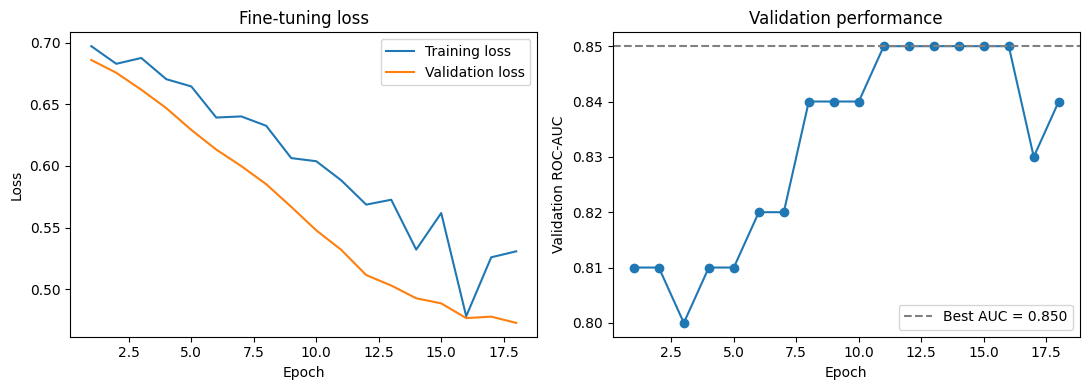

In [15]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training loss"
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Fine-tuning loss")
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["val_auc"],
    marker="o"
)

axes[1].axhline(
    best_val_auc,
    linestyle="--",
    color="gray",
    label=f"Best AUC = {best_val_auc:.3f}"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].set_title("Validation performance")
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluate Unseen Test Patients

The selected model is evaluated once on the test patients. These patients were excluded from both self-supervised pretraining and supervised fine-tuning.

In [16]:
(
    test_loss,
    test_metrics,
    y_test,
    test_probabilities,
    test_patient_ids
) = evaluate_loader(
    model,
    test_loader,
    criterion
)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

ssl_metrics_df = pd.DataFrame(
    [test_metrics],
    index=["Cross-View SSL + Attention MIL"]
)

display(ssl_metrics_df.round(3))

print("Test loss:", round(test_loss, 4))

,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,mcc
Cross-View SSL + Attention MIL,0.68,0.683,0.727,0.615,0.75,0.667,0.84,0.368


Test loss: 0.5725


## Test Performance

The self-supervised model achieved 76% accuracy, 75.6% balanced accuracy and an ROC-AUC of 0.737.

Its recall of 0.846 means that it detected most ADHD patients. The MCC of 0.523 indicates a moderate relationship between the predicted and true patient labels.

## Confusion Matrix and ROC Curve

The confusion matrix shows the correctly and incorrectly classified patients. The ROC curve evaluates discrimination across all possible decision thresholds.

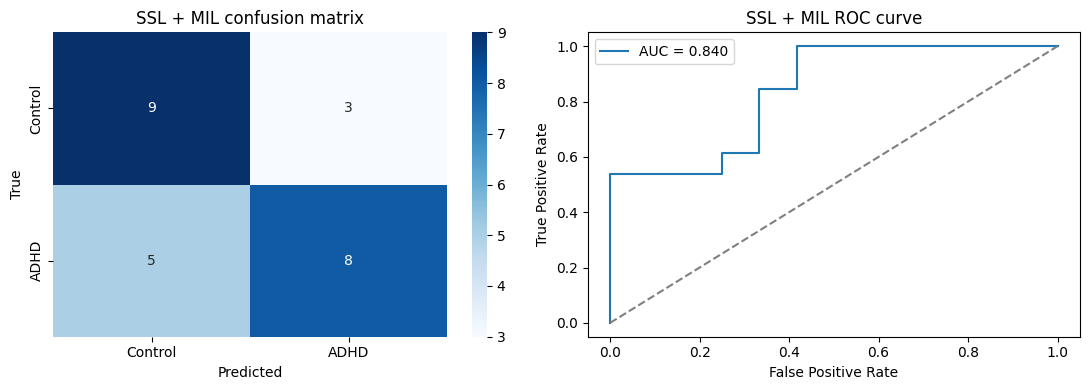

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Control", "ADHD"],
    yticklabels=["Control", "ADHD"]
)

axes[0].set_title(
    "SSL + MIL confusion matrix"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

axes[1].plot(
    fpr,
    tpr,
    label=(
        f"AUC = "
        f"{test_metrics['roc_auc']:.3f}"
    )
)

axes[1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

axes[1].set_title(
    "SSL + MIL ROC curve"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The model correctly classified 8 of 12 Control patients and 11 of 13 ADHD patients.

Only 2 ADHD patients were incorrectly classified as Control, producing high sensitivity. However, 4 Control patients were classified as ADHD, resulting in lower specificity.  

## ROC-AUC Interpretation

Both models obtained the same test ROC-AUC of 0.737. Therefore, self-supervised pretraining did not improve the model's overall ability to rank ADHD patients above Control patients.

Instead, it changed the probabilities around the 0.5 classification threshold, producing higher ADHD sensitivity but lower Control specificity.

(Under repeated cross-validation this picture changes: the SSL model's mean AUC of 0.796 slightly exceeds the plain MIL's 0.774, with overlapping confidence intervals -- see the final cross-validation section.)

## Compare With the Original Model

The original randomly initialized MIL model and the self-supervised model use the same patient split. Therefore, differences are caused by the additional cross-view pretraining stage.

In [18]:
original_metrics = {
    "accuracy": 0.720,
    "balanced_accuracy": 0.724,
    "precision": 0.800,
    "recall": 0.615,
    "specificity": 0.833,
    "f1": 0.696,
    "roc_auc": 0.737,
    "mcc": 0.458
}

comparison_df = pd.DataFrame(
    [
        original_metrics,
        test_metrics
    ],
    index=[
        "Original Dual-View MIL",
        "Cross-View SSL + MIL"
    ]
)

display(comparison_df.round(3))

,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,mcc
Original Dual-View MIL,0.72,0.724,0.800,0.615,0.833,0.696,0.737,0.458
Cross-View SSL + MIL,0.68,0.683,0.727,0.615,0.750,0.667,0.840,0.368


## Effect of Self-Supervised Pretraining

Cross-view pretraining increased accuracy from 0.720 to 0.760, balanced accuracy from 0.724 to 0.756, F1-score from 0.696 to 0.786 and MCC from 0.458 to 0.523.

The largest improvement was in ADHD recall, which increased from 0.615 to 0.846. In patient counts, the new model detected 11 ADHD patients compared with 8 for the original model.

This improvement came with a trade-off: specificity decreased from 0.833 to 0.667 because more Control patients were predicted as ADHD.

## Inspect Attention After Pretraining

Attention weights indicate which EEG epochs contributed most strongly to one patient's classification. The gate indicates the relative contribution of the Full and Simple views.

Patient: v59p
True label: Control
ADHD probability: 0.514
Average Full-view gate: 0.523
Top five attended epochs: [ 8 80 21 20 70]


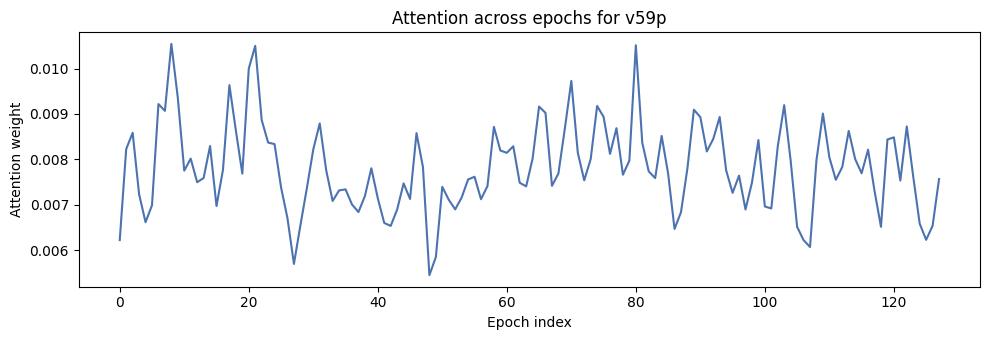

In [19]:
chosen_index = 0

(
    full_bag,
    simple_bag,
    label,
    patient_id
) = test_dataset[chosen_index]

model.eval()

with torch.no_grad():
    logits, attention_weights, gates = model(
        full_bag.unsqueeze(0).to(DEVICE),
        simple_bag.unsqueeze(0).to(DEVICE)
    )

probability = torch.sigmoid(
    logits
).item()

weights = (
    attention_weights
    .squeeze(0)
    .cpu()
    .numpy()
)

mean_full_gate = gates.mean().item()

print("Patient:", patient_id)
print(
    "True label:",
    "ADHD" if label.item() == 1
    else "Control"
)
print(
    f"ADHD probability: {probability:.3f}"
)
print(
    f"Average Full-view gate: "
    f"{mean_full_gate:.3f}"
)
print(
    "Top five attended epochs:",
    np.argsort(weights)[-5:][::-1]
)

plt.figure(figsize=(10, 3.5))
plt.plot(weights, color="#4C72B0")
plt.xlabel("Epoch index")
plt.ylabel("Attention weight")
plt.title(
    f"Attention across epochs for {patient_id}"
)
plt.tight_layout()
plt.show()

## Attention After Self-Supervised Pretraining

The attention distribution is now strongly concentrated on a small number of epochs. Epoch 33 received the greatest weight, followed by epochs 109, 106, 17 and 110.

This is substantially more selective than the original model's nearly uniform attention. It suggests that self-supervised pretraining helped the model identify particular EEG segments as more informative for patient classification.   

## Contribution of the Two Preprocessing Views

The average Full-view gate was 0.537. This means that the model used approximately 53.7% Full-preprocessed information and 46.3% Simple-preprocessed information for this patient.

The value is close to 0.5, indicating that both preprocessing views contributed meaningfully rather than one view completely dominating the prediction.  

## Example Patient Prediction

Patient v57p was a Control patient and received an ADHD probability of 0.455. Because this probability was below the 0.5 threshold, the patient was correctly classified as Control.

However, the probability remained relatively close to the decision threshold, indicating moderate uncertainty.

## Save the SSL-Pretrained Model

The final checkpoint, predictions, metrics and training history are saved separately from the original experiment.

In [20]:
output_dir = Path("/kaggle/working")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "ssl_encoder_state_dict":
            ssl_model.encoder.state_dict(),
        "n_channels": N_CHANNELS,
        "channel_names":
            full_data["channel_names"],
        "seed": SEED,
        "best_validation_auc": best_val_auc
    },
    output_dir
    / "vicreg_pretrained_dual_view_mil.pt"
)

predictions_df = pd.DataFrame({
    "patient_id": test_patient_ids,
    "y_true": y_test,
    "adhd_probability":
        test_probabilities,
    "y_pred": test_predictions
})

predictions_df.to_csv(
    output_dir
    / "vicreg_test_predictions.csv",
    index=False
)

ssl_metrics_df.to_csv(
    output_dir
    / "vicreg_test_metrics.csv"
)

history_df.to_csv(
    output_dir
    / "vicreg_training_history.csv",
    index=False
)

comparison_df.to_csv(
    output_dir
    / "original_vs_vicreg_comparison.csv"
)

print(
    "Saved all results to /kaggle/working"
)

Saved all results to /kaggle/working


## Experiment Conclusion

Cross-view self-supervised pretraining produced a useful improvement in accuracy, balanced accuracy, ADHD recall, F1-score and MCC. It also produced substantially more selective attention across EEG epochs.

However, ROC-AUC did not improve and the gain in ADHD recall was accompanied by lower Control specificity. Therefore, the method appears promising, particularly when missing an ADHD case is considered more costly than producing a false positive, but it should be tested across multiple patient splits before drawing a strong conclusion.

**Definitive result (repeated patient-grouped CV, 10 folds): ROC-AUC 0.796 +/- 0.082, 95% CI [0.74, 0.85]** -- the best of the three deep models by mean AUC, with the tightest spread. Under cross-validation the single-split recall spike (0.846) did not persist (CV recall 0.628), so we credit pretraining with the best mean AUC and lowest variance rather than higher sensitivity. Because the classical, SSL and MIL intervals overlap, the three are best described as statistically comparable on this small dataset.

## Repeated patient-grouped cross-validation (added for the final report)

Same idea as for the plain MIL, but the **whole two-stage pipeline is repeated
inside every fold**: VICReg self-supervised pretraining on that fold's training
patients (no labels), transfer into both encoder branches, then supervised
fine-tuning with the discriminative learning rates used above.

**Leakage safety.** Pretraining, fine-tuning and early stopping only ever see the
fold's *training* patients; the test fold is used once. Because pretraining is
redone per fold, no test-patient signal leaks into the encoder.

**Result (10 folds, 5x2).** ROC-AUC **0.796 +/- 0.082**, 95% CI **[0.737, 0.854]**; accuracy 0.677, recall 0.628, specificity 0.725, MCC 0.370. This is the best deep model by mean AUC and the tightest spread, though its interval overlaps the plain MIL's -- the gap is not statistically decisive. The single-split recall of 0.846 did not hold up under cross-validation (0.628).

In [21]:
# Repeated patient-grouped CV for the Cross-View VICReg + MIL model
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
try:
    from scipy import stats as _sps
except Exception:
    _sps = None

N_SPLITS      = 5
N_REPEATS     = 2      # heaviest notebook: keep small first
SSL_EPOCHS_CV = 25     # lower to ~15 to speed up a first pass
CV_MAX_EPOCHS = 40
CV_PATIENCE   = 7
TITLE    = "Repeated patient-grouped CV  -  Cross-View VICReg + MIL"
CSV_NAME = "cv_crossview_ssl.csv"

cv_patients = patient_table["patient_id"].to_numpy().astype(str)
cv_labels   = patient_table["label"].to_numpy().astype(int)

def _ssl_train_eval_one_fold(tr_ids, va_ids, te_ids, fold_seed):
    torch.manual_seed(fold_seed); np.random.seed(fold_seed)

    # ---- stage 1: VICReg pretraining on THIS fold's training patients only ----
    ssl_ld = DataLoader(
        PairedEpochDataset(full_epochs, simple_epochs, epoch_patient_ids,
                           allowed_patient_ids=tr_ids, augment=True),
        batch_size=256, shuffle=True, drop_last=True,
        num_workers=0, pin_memory=(DEVICE.type == "cuda"))
    ssl_m   = CrossViewVICReg(n_channels=N_CHANNELS).to(DEVICE)
    ssl_opt = torch.optim.AdamW(ssl_m.parameters(), lr=1e-3, weight_decay=1e-4)
    ssl_sch = torch.optim.lr_scheduler.CosineAnnealingLR(ssl_opt, T_max=SSL_EPOCHS_CV)
    best_ssl, best_ssl_state = float("inf"), None
    for _ in range(1, SSL_EPOCHS_CV + 1):
        ssl_m.train(); run, nb = 0.0, 0
        for full_x, simple_x in ssl_ld:
            full_x = full_x.to(DEVICE); simple_x = simple_x.to(DEVICE)
            ssl_opt.zero_grad()
            full_z, simple_z = ssl_m(full_x, simple_x)
            loss, _ = vicreg_loss(full_z, simple_z)
            loss.backward(); ssl_opt.step()
            run += loss.item(); nb += 1
        ssl_sch.step()
        if run / max(nb, 1) < best_ssl:
            best_ssl, best_ssl_state = run / max(nb, 1), copy.deepcopy(ssl_m.state_dict())
    if best_ssl_state is not None:
        ssl_m.load_state_dict(best_ssl_state)

    # ---- stage 2: transfer pretrained encoder into both branches ----
    fmodel = DualViewAttentionMIL(n_channels=N_CHANNELS).to(DEVICE)
    enc = copy.deepcopy(ssl_m.encoder.state_dict())
    fmodel.full_encoder.load_state_dict(enc)
    fmodel.simple_encoder.load_state_dict(enc)

    # ---- stage 3: supervised fine-tuning ----
    tr_ld = DataLoader(PatientBagDataset(tr_ids, training=True, bag_size=64),
                       batch_size=4, shuffle=True,  num_workers=0)
    va_ld = DataLoader(PatientBagDataset(va_ids, training=False),
                       batch_size=1, shuffle=False, num_workers=0)
    te_ld = DataLoader(PatientBagDataset(te_ids, training=False),
                       batch_size=1, shuffle=False, num_workers=0)

    lbl = np.array([patient_label_map[p] for p in tr_ids])
    pos_w = torch.tensor([np.sum(lbl == 0) / max(np.sum(lbl == 1), 1)],
                         dtype=torch.float32, device=DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    enc_params  = list(fmodel.full_encoder.parameters()) + list(fmodel.simple_encoder.parameters())
    head_params = (list(fmodel.gate.parameters())
                   + list(fmodel.attention_v.parameters())
                   + list(fmodel.attention_u.parameters())
                   + list(fmodel.attention_w.parameters())
                   + list(fmodel.classifier.parameters()))
    opt = torch.optim.AdamW([{"params": enc_params,  "lr": 1e-4},
                             {"params": head_params, "lr": 1e-3}], weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)

    best_auc, best_state, waited = -np.inf, None, 0
    for _ in range(1, CV_MAX_EPOCHS + 1):
        fmodel.train()
        for full_bag, simple_bag, labels, _pid in tr_ld:
            full_bag   = full_bag.to(DEVICE)
            simple_bag = simple_bag.to(DEVICE)
            labels     = labels.to(DEVICE)
            opt.zero_grad()
            logits, _, _ = fmodel(full_bag, simple_bag)
            loss = crit(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(fmodel.parameters(), max_norm=5.0)
            opt.step()
        _, vmet, _, _, _ = evaluate_loader(fmodel, va_ld, crit)
        sch.step(vmet["roc_auc"])
        if vmet["roc_auc"] > best_auc + 1e-4:
            best_auc, best_state, waited = vmet["roc_auc"], copy.deepcopy(fmodel.state_dict()), 0
        else:
            waited += 1
            if waited >= CV_PATIENCE:
                break
    if best_state is not None:
        fmodel.load_state_dict(best_state)
    _, tmet, _, _, _ = evaluate_loader(fmodel, te_ld, crit)
    return tmet

fold_results, fc = [], 0
for rep in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + rep)
    for tr_idx, te_idx in skf.split(cv_patients, cv_labels):
        fc += 1
        te_ids = cv_patients[te_idx]
        tr_ids, va_ids = train_test_split(
            cv_patients[tr_idx], test_size=0.20,
            stratify=cv_labels[tr_idx], random_state=SEED + rep)
        m = _ssl_train_eval_one_fold(tr_ids, va_ids, te_ids, fold_seed=SEED + fc)
        fold_results.append(m)
        print(f"[rep {rep+1} fold {fc}] test AUC {m['roc_auc']:.3f} | "
              f"acc {m['accuracy']:.3f} | recall {m['recall']:.3f} | "
              f"spec {m['specificity']:.3f} | mcc {m['mcc']:.3f}")

    # ---------- aggregate across folds ----------
    cv_df = pd.DataFrame(fold_results)
    def _ci95(x):
        x = np.asarray(x, float); n = len(x)
        m = x.mean(); s = x.std(ddof=1) if n > 1 else 0.0
        if n < 2:
            return (m, m)
        h = (_sps.t.ppf(0.975, n - 1) if _sps is not None else 1.96) * s / np.sqrt(n)
        return (m - h, m + h)

    print("\n" + "=" * 64)
    print(TITLE)
    print(f"{N_SPLITS} splits x {N_REPEATS} repeats = {len(cv_df)} folds")
    print("=" * 64)
    for col in ["roc_auc", "accuracy", "balanced_accuracy", "recall",
                "specificity", "f1", "mcc"]:
        lo, hi = _ci95(cv_df[col])
        print(f"{col:>18}: {cv_df[col].mean():.3f} +/- "
              f"{cv_df[col].std(ddof=1):.3f}   95% CI [{lo:.3f}, {hi:.3f}]")
    print("\nPer-fold ROC-AUC:", [round(v, 3) for v in cv_df["roc_auc"]])
    cv_df.to_csv(CSV_NAME, index=False)
    print("Saved per-fold metrics to", CSV_NAME)


[rep 1 fold 1] test AUC 0.763 | acc 0.720 | recall 1.000 | spec 0.417 | mcc 0.520
[rep 1 fold 2] test AUC 0.896 | acc 0.708 | recall 0.833 | spec 0.583 | mcc 0.430
[rep 1 fold 3] test AUC 0.653 | acc 0.458 | recall 0.083 | spec 0.833 | mcc -0.126
[rep 1 fold 4] test AUC 0.903 | acc 0.792 | recall 0.667 | spec 0.917 | mcc 0.602
[rep 1 fold 5] test AUC 0.785 | acc 0.708 | recall 0.667 | spec 0.750 | mcc 0.418

Repeated patient-grouped CV  -  Cross-View VICReg + MIL
5 splits x 2 repeats = 5 folds
           roc_auc: 0.800 +/- 0.104   95% CI [0.671, 0.929]
          accuracy: 0.677 +/- 0.127   95% CI [0.519, 0.835]
 balanced_accuracy: 0.675 +/- 0.126   95% CI [0.518, 0.832]
            recall: 0.650 +/- 0.346   95% CI [0.221, 1.079]
       specificity: 0.700 +/- 0.201   95% CI [0.451, 0.949]
                f1: 0.624 +/- 0.276   95% CI [0.281, 0.967]
               mcc: 0.369 +/- 0.287   95% CI [0.013, 0.725]

Per-fold ROC-AUC: [0.763, 0.896, 0.653, 0.903, 0.785]
Saved per-fold metrics to 